In [ ]:
#import sys
#print(sys.version)

In [ ]:
# Instalar las librerias necesarias:
# - opencv-python: Libreria para captura de video y procesamiento de imagenes
# - mediapipe: Framework de Google para deteccion de manos y gestos
#pip install opencv-python mediapipe

In [ ]:
# Desinstalar mediapipe por si hay conflictos de versiones
#!pip uninstall mediapipe -y

In [ ]:
# Instalar una version especifica de mediapipe (0.10.14) para asegurar compatibilidad
#pip install mediapipe==0.10.14

In [ ]:
# Verificar que mediapipe se haya instalado correctamente
# Se imprime la version y se verifica que exista el modulo 'solutions'
#import mediapipe as mp

#print(mp.__version__)
#print(hasattr(mp, "solutions"))

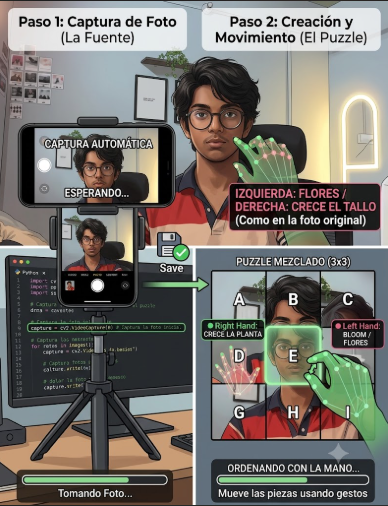

In [ ]:
# ====================================================================
# PROGRAMA: PUZZLE DE GESTOS CON LA MANO (Version 1 - Basica)
#
# Descripcion:
# Este programa implementa un puzzle de 3x3 que se controla moviendo
# la mano frente a la camara. Cada celda del puzzle contiene un numero
# del 0 al 8. El objetivo es ordenar los numeros en su posicion correcta
# moviendo la mano sobre las celdas.
#
# Mecanica:
# - La posicion media de las puntas de los dedos determina la celda
#   seleccionada.
# - Cuando la mano se mueve a una celda diferente, se intercambia
#   la pieza actual con la que estaba en esa posicion.
# - Si una pieza queda en su lugar correcto, se marca con borde verde.
# - El juego termina cuando todas las piezas estan en orden.
#
# Librerias:
# - OpenCV, MediaPipe, NumPy, random, time
# ====================================================================
import cv2
import mediapipe as mp
import numpy as np
import random
import time

# --- CONFIGURACION DEL PUZZLE ---
# ROWS y COLS: Dimensiones de la cuadricula (3x3 = 9 piezas).
# FRAME_WIDTH / FRAME_HEIGHT: Resolucion de captura de video.
# PIECE_WIDTH / PIECE_HEIGHT: Tamano de cada celda en pixeles.
ROWS = 3
COLS = 3
FRAME_WIDTH = 640
FRAME_HEIGHT = 480
PIECE_WIDTH = FRAME_WIDTH // COLS
PIECE_HEIGHT = FRAME_HEIGHT // ROWS

# --- INICIALIZACION DE MEDIAPIPE ---
# Se configura el detector de manos con seguimiento de alta precision.
# max_num_hands=1: Solo se necesita una mano para controlar el puzzle.
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7, min_tracking_confidence=0.7)
mp_draw = mp.solutions.drawing_utils

# --- INICIALIZACION DE LA CAMARA ---
# Se configura la resolucion de captura para que coincida con la cuadricula.
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_HEIGHT)

# --- VARIABLES DE ESTADO DEL JUEGO ---
# correct_pieces: Lista de IDs de piezas que ya estan en su posicion correcta.
# all_piece_ids: Lista desordenada de IDs de piezas (posicion actual en la cuadricula).
# score: Puntuacion acumulada (+10 por cada pieza correcta).
# last_piece_moved_id: Control para evitar mover la misma pieza repetidamente.
# last_hand_pos: Ultima posicion (fila, columna) donde se detecto la mano.
# is_setup_done: Bandera que indica si el puzzle ya fue inicializado.
correct_pieces = []
all_piece_ids = []
score = 0
last_piece_moved_id = -1
last_hand_pos = None
is_setup_done = False

def draw_grid(frame, score, correct_pieces):
    """
    Dibuja la cuadricula del puzzle y la puntuacion en pantalla.
    
    Parametros:
        frame: Imagen sobre la cual dibujar.
        score: Puntuacion actual del jugador.
        correct_pieces: Lista de piezas colocadas correctamente.
    """
    # Dibujar las lineas de la cuadricula 3x3 en blanco.
    for r in range(ROWS + 1):
        y = r * PIECE_HEIGHT
        cv2.line(frame, (0, y), (FRAME_WIDTH, y), (255, 255, 255), 2)
    for c in range(COLS + 1):
        x = c * PIECE_WIDTH
        cv2.line(frame, (x, 0), (x, FRAME_HEIGHT), (255, 255, 255), 2)

    # Resaltar con borde verde las piezas que ya estan en su lugar correcto.
    for piece_id in correct_pieces:
        r = piece_id // COLS
        c = piece_id % COLS
        y1, x1 = r * PIECE_HEIGHT, c * PIECE_WIDTH
        cv2.rectangle(frame, (x1, y1), (x1 + PIECE_WIDTH, y1 + PIECE_HEIGHT), (0, 255, 0), 4)

    # Mostrar la puntuacion en la esquina superior izquierda.
    cv2.putText(frame, f"Score: {score}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

    # Mostrar instrucciones en la parte inferior de la pantalla.
    cv2.putText(frame, "Mueve la mano para armar el puzzle", (10, FRAME_HEIGHT - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

# --- BUCLE PRINCIPAL DE PROCESAMIENTO ---
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Voltear horizontalmente para efecto espejo (movimiento mas intuitivo).
    frame = cv2.flip(frame, 1)

    # Convertir el frame de BGR a RGB (formato que requiere MediaPipe).
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)

    # --- INICIALIZACION DEL PUZZLE ---
    # En el primer frame, se crea la lista de IDs y se desordenan.
    if not is_setup_done:
        all_piece_ids = list(range(ROWS * COLS))
        random.shuffle(all_piece_ids)
        is_setup_done = True

    # --- DETECCION DE LA MANO Y CALCULO DE POSICION ---
    if results.multi_hand_landmarks:
        hand_landmarks = results.multi_hand_landmarks[0]
        mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        # Se recolectan las coordenadas de las puntas de los 4 dedos
        # (indice, medio, anular, menique) para calcular la posicion media
        # de la mano. Esto da una posicion mas estable que usar un solo punto.
        finger_tips_x = []
        finger_tips_y = []
        for landmark in hand_landmarks.landmark:
            if landmark == hand_landmarks.landmark[mp_hands.HandLandmark.INDEX_FINGER_TIP] or \
               landmark == hand_landmarks.landmark[mp_hands.HandLandmark.MIDDLE_FINGER_TIP] or \
               landmark == hand_landmarks.landmark[mp_hands.HandLandmark.RING_FINGER_TIP] or \
               landmark == hand_landmarks.landmark[mp_hands.HandLandmark.PINKY_TIP]:
                finger_tips_x.append(int(landmark.x * FRAME_WIDTH))
                finger_tips_y.append(int(landmark.y * FRAME_HEIGHT))

        # Promedio de las coordenadas de las puntas de los dedos.
        mean_hand_x = int(np.mean(finger_tips_x))
        mean_hand_y = int(np.mean(finger_tips_y))

        # Determinar la celda de la cuadricula donde apunta la mano.
        current_col = mean_hand_x // PIECE_WIDTH
        current_row = mean_hand_y // PIECE_HEIGHT

        # Limitar los valores para que no se salgan de la cuadricula.
        current_col = max(0, min(current_col, COLS - 1))
        current_row = max(0, min(current_row, ROWS - 1))

        # Calcular el ID de la pieza en la posicion actual.
        current_piece_id = current_row * COLS + current_col

        # --- LOGICA DE MOVIMIENTO ---
        # Si la mano se mueve a una celda diferente...
        if last_hand_pos != (current_row, current_col):
            # ...y la pieza actual no es la que acabamos de mover...
            if current_piece_id != last_piece_moved_id:
                # Buscar que ID de pieza esta actualmente en esta celda.
                piece_index = all_piece_ids.index(current_piece_id)
                mixed_piece_id = all_piece_ids[piece_index]

                # Si la pieza en esta celda coincide con su ID original
                # (es decir, esta en su lugar correcto), se marca como fija.
                if mixed_piece_id == current_piece_id and current_piece_id not in correct_pieces:
                    correct_pieces.append(current_piece_id)
                    score += 10
                    print(f"Pieza {current_piece_id} colocada correctamente!")

                last_piece_moved_id = mixed_piece_id
                print(f"Mano movida a celda ({current_row}, {current_col}), Pieza ID: {mixed_piece_id}")

            last_hand_pos = (current_row, current_col)

        # --- VERIFICACION DE VICTORIA ---
        if len(correct_pieces) == ROWS * COLS:
            cv2.putText(frame, "PUZZLE COMPLETADO!", (100, FRAME_HEIGHT // 2), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 5)
            # Si se completo el puzzle, esperar 5 segundos y reiniciar.
            if 'win_time' not in locals():
                win_time = time.time()
            elif time.time() - win_time > 5:
                correct_pieces = []
                score = 0
                all_piece_ids = list(range(ROWS * COLS))
                random.shuffle(all_piece_ids)
                last_piece_moved_id = -1
                last_hand_pos = None
                del win_time

    # --- DIBUJADO DE LA INTERFAZ ---
    draw_grid(frame, score, correct_pieces)

    # Mostrar el resultado en una ventana.
    cv2.imshow("Hand Control Puzzle", frame)

    # Salir si se presiona ESC.
    if cv2.waitKey(1) & 0xFF == 27 or cv2.getWindowProperty("Hand Control Puzzle", cv2.WND_PROP_VISIBLE) < 1:
        break

# --- LIBERACION DE RECURSOS ---
cap.release()
cv2.destroyAllWindows()

In [ ]:
# ====================================================================
# PROGRAMA: PUZZLE DE GESTOS CON FOTO (Version 2 - Puntero)
#
# Descripcion:
# Este programa permite al usuario tomar una foto con la camara y luego
# resolver un puzzle de 3x3 arrastrando las piezas con el dedo indice.
# El puzzle se genera a partir de la foto capturada, dividiendola en
# 9 fragmentos que se desordenan aleatoriamente.
#
# Mecanica:
# 1. CAMARA: Muestra el video en vivo y espera que se presione ESPACIO.
# 2. CUENTA_REGRESIVA: Cuenta 3 segundos y captura la foto.
# 3. JUEGO: El usuario arrastra piezas con el dedo indice.
#    - Al tocar una pieza con el dedo, esta se "pega" al cursor.
#    - Al retirar el dedo (dejar de detectar la mano), la pieza se suelta.
#    - Si la pieza esta cerca de su posicion correcta, se encaja.
# 4. VICTORIA: Muestra la foto completa con un mensaje de exito.
#
# Librerias:
# - OpenCV, MediaPipe, NumPy, random, time
# ====================================================================
import cv2
import mediapipe as mp
import numpy as np
import random
import time

# --- CONFIGURACION DEL PUZZLE ---
# FILAS y COLUMNAS: Dimensiones de la cuadricula (3x3 = 9 piezas).
# ANCHO / ALTO: Resolucion de captura y de la cuadricula.
# ANCHO_PIEZA / ALTO_PIEZA: Tamano de cada celda en pixeles.
FILAS = 3
COLUMNAS = 3
ANCHO = 640
ALTO = 480
ANCHO_PIEZA = ANCHO // COLUMNAS
ALTO_PIEZA = ALTO // FILAS

# --- INICIALIZACION DE MEDIAPIPE Y CAMARA ---
# mp_hands: Modulo de deteccion de manos.
# hands: Detector configurado para 1 mano con 70% de confianza minima.
# mp_draw: Utilidad para dibujar el esqueleto de la mano.
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7)
mp_draw = mp.solutions.drawing_utils

# Se abre la camara y se configura la resolucion.
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, ANCHO)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, ALTO)

# --- VARIABLES DE ESTADO DEL JUEGO ---
# Estados posibles: "CAMARA", "CUENTA_REGRESIVA", "JUEGO", "VICTORIA"
# tiempo_inicio: Marca temporal para la cuenta regresiva.
# foto_capturada: Almacena el frame que se uso como foto del puzzle.
estado = "CAMARA"
tiempo_inicio = 0
foto_capturada = None

# --- CLASE PIEZA ---
# Representa un fragmento del puzzle.
# Atributos:
#   id_original: Posicion correcta que debe ocupar (0 a 8).
#   imagen: El fragmento de imagen recortado de la foto original.
#   x, y: Posicion actual en la pantalla (esquina superior izquierda).
#   fija: Indica si ya esta en su lugar correcto (no se puede mover mas).
class Pieza:
    def __init__(self, id_original, imagen, x_actual, y_actual):
        self.id_original = id_original
        self.imagen = imagen
        self.x = x_actual
        self.y = y_actual
        self.fija = False

# Lista de todas las piezas del puzzle.
piezas = []
# Pieza que el usuario esta arrastrando actualmente (None si no hay ninguna).
pieza_seleccionada = None

def inicializar_puzzle(foto):
    """
    Corta la foto en 9 piezas (3x3), las desordena aleatoriamente
    y las coloca en la cuadricula para comenzar el juego.
    
    Parametros:
        foto: Imagen capturada de la camara que sera el puzzle.
    """
    global piezas
    piezas = []
    
    # 1. Recorrer la cuadricula y recortar cada fragmento de la foto original.
    piezas_temporales = []
    for f in range(FILAS):
        for c in range(COLUMNAS):
            y1, y2 = f * ALTO_PIEZA, (f + 1) * ALTO_PIEZA
            x1, x2 = c * ANCHO_PIEZA, (c + 1) * ANCHO_PIEZA
            fragmento = foto[y1:y2, x1:x2]
            
            # Cada fragmento tiene un ID = fila * COLUMNAS + columna
            id_original = f * COLUMNAS + c
            piezas_temporales.append((id_original, fragmento))
    
    # 2. Desordenar los fragmentos para mezclar el puzzle.
    random.shuffle(piezas_temporales)
    
    # 3. Colocar cada fragmento desordenado en una posicion de la cuadricula.
    idx = 0
    for f in range(FILAS):
        for c in range(COLUMNAS):
            id_orig, frag = piezas_temporales[idx]
            x_ini = c * ANCHO_PIEZA
            y_ini = f * ALTO_PIEZA
            
            # Si por casualidad la pieza quedo en su lugar correcto,
            # se marca como fija inmediatamente.
            pos_actual_id = f * COLUMNAS + c
            es_fija = (id_orig == pos_actual_id)
            
            piezas.append(Pieza(id_orig, frag, x_ini, y_ini))
            piezas[-1].fija = es_fija
            idx += 1

# --- BUCLE PRINCIPAL ---
while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # Voltear horizontalmente para efecto espejo.
    frame = cv2.flip(frame, 1)
    # Convertir BGR a RGB para MediaPipe.
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)
    
    pos_indice = None

    # --- DETECCION DE LA MANO ---
    # Se usa el landmark 8 (punta del dedo indice) como cursor.
    if results.multi_hand_landmarks:
        mano = results.multi_hand_landmarks[0]
        mp_draw.draw_landmarks(frame, mano, mp_hands.HAND_CONNECTIONS)
        
        # Obtener coordenadas de la punta del dedo indice.
        idx_landmark = mano.landmark[8]
        pos_indice = (int(idx_landmark.x * ANCHO), int(idx_landmark.y * ALTO))
        cv2.circle(frame, pos_indice, 10, (0, 255, 0), cv2.FILLED)

    # --- MAQUINA DE ESTADOS ---
    # El juego tiene 4 estados que determinan el comportamiento del programa.
    
    if estado == "CAMARA":
        # Estado inicial: mostrar el video en vivo e instrucciones.
        cv2.putText(frame, "Presiona ESPACIO para tomar foto", (50, ALTO // 2), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        
    elif estado == "CUENTA_REGRESIVA":
        # Cuenta regresiva de 3 segundos antes de capturar la foto.
        tiempo_transcurrido = time.time() - tiempo_inicio
        cuenta = 3 - int(tiempo_transcurrido)
        
        if cuenta > 0:
            cv2.putText(frame, str(cuenta), (ANCHO // 2 - 20, ALTO // 2), 
                        cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 255), 5)
        else:
            # Capturar el frame actual como foto base del puzzle.
            foto_capturada = frame.copy()
            inicializar_puzzle(foto_capturada)
            estado = "JUEGO"

    elif estado == "JUEGO":
        # Crear un lienzo en negro para dibujar el puzzle.
        pantalla_juego = np.zeros_like(frame)
        
        # --- LOGICA DE ARRASTRE CON EL DEDO INDICE ---
        # Si el dedo esta sobre una pieza no fija, se selecciona.
        if pos_indice and pieza_seleccionada is None:
            for pieza in piezas:
                if not pieza.fija:
                    # Verificar si el dedo esta dentro del area de la pieza.
                    if (pieza.x < pos_indice[0] < pieza.x + ANCHO_PIEZA) and \
                       (pieza.y < pos_indice[1] < pieza.y + ALTO_PIEZA):
                        pieza_seleccionada = pieza
                        break
        
        # Mientras se detecte el dedo, la pieza sigue al cursor.
        if pos_indice and pieza_seleccionada:
            pieza_seleccionada.x = pos_indice[0] - ANCHO_PIEZA // 2
            pieza_seleccionada.y = pos_indice[1] - ALTO_PIEZA // 2
        else:
            # Si no se detecta el dedo, soltar la pieza.
            if pieza_seleccionada:
                # Calcular la celda mas cercana a donde se solto la pieza.
                celda_c = round(pieza_seleccionada.x / ANCHO_PIEZA)
                celda_f = round(pieza_seleccionada.y / ALTO_PIEZA)
                
                # Limitar dentro de la cuadricula.
                celda_c = max(0, min(celda_c, COLUMNAS - 1))
                celda_f = max(0, min(celda_f, FILAS - 1))
                
                id_destino = celda_f * COLUMNAS + celda_c
                
                # Si la pieza esta en su posicion correcta, se fija.
                if pieza_seleccionada.id_original == id_destino:
                    pieza_seleccionada.x = celda_c * ANCHO_PIEZA
                    pieza_seleccionada.y = celda_f * ALTO_PIEZA
                    pieza_seleccionada.fija = True
                
                pieza_seleccionada = None

        # --- DIBUJADO DE LAS PIEZAS ---
        for pieza in piezas:
            # Recortar la parte visible de la pieza (evita desbordes).
            x1, y1 = max(0, pieza.x), max(0, pieza.y)
            x2, y2 = min(ANCHO, pieza.x + ANCHO_PIEZA), min(ALTO, pieza.y + ALTO_PIEZA)
            
            img_w = x2 - x1
            img_h = y2 - y1
            
            if img_w > 0 and img_h > 0:
                frag_x1 = max(0, -pieza.x)
                frag_y1 = max(0, -pieza.y)
                pantalla_juego[y1:y2, x1:x2] = pieza.imagen[frag_y1:frag_y1+img_h, frag_x1:frag_x1+img_w]
            
            # Borde verde si esta fija, blanco si se puede mover.
            color_borde = (0, 255, 0) if pieza.fija else (255, 255, 255)
            cv2.rectangle(pantalla_juego, (pieza.x, pieza.y), (pieza.x + ANCHO_PIEZA, pieza.y + ALTO_PIEZA), color_borde, 2)

        # Dibujar las lineas guia de la cuadricula.
        for f in range(FILAS + 1):
            cv2.line(pantalla_juego, (0, f * ALTO_PIEZA), (ANCHO, f * ALTO_PIEZA), (50, 50, 50), 1)
        for c in range(COLUMNAS + 1):
            cv2.line(pantalla_juego, (c * ANCHO_PIEZA, 0), (c * ANCHO_PIEZA, ALTO), (50, 50, 50), 1)

        # Mostrar el cursor del dedo sobre las piezas.
        if pos_indice:
            cv2.circle(pantalla_juego, pos_indice, 10, (0, 255, 0), cv2.FILLED)

        # Reemplazar el frame de la camara con el lienzo del puzzle.
        frame = pantalla_juego

        # Verificar si todas las piezas estan fijas (condicion de victoria).
        if all(pieza.fija for pieza in piezas):
            estado = "VICTORIA"

    elif estado == "VICTORIA":
        # Mostrar la foto original completa con mensaje de victoria.
        frame = foto_capturada.copy()
        cv2.putText(frame, "iCOMPLETADO!", (120, ALTO // 2), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 255, 0), 4)
        cv2.putText(frame, "Presiona R para reiniciar", (140, ALTO // 2 + 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # --- CONTROLES DE TECLADO ---
    cv2.imshow("Puzzle de Gestos con Foto", frame)
    key = cv2.waitKey(1) & 0xFF
    
    if key == ord(' '):  # ESPACIO: iniciar cuenta regresiva
        if estado == "CAMARA":
            tiempo_inicio = time.time()
            estado = "CUENTA_REGRESIVA"
            
    elif key == ord('r') or key == ord('R'):  # R: reiniciar el juego
        estado = "CAMARA"
        pieza_seleccionada = None
        
    elif key == 27 or cv2.getWindowProperty("Puzzle de Gestos con Foto", cv2.WND_PROP_VISIBLE) < 1:  # ESC: salir del programa
        break

# --- LIBERACION DE RECURSOS ---
cap.release()
cv2.destroyAllWindows()

In [ ]:
# ====================================================================
# PROGRAMA: PUZZLE DE GESTOS CON PINZA (Version 3 - Pegajoso)
#
# Descripcion:
# Version mejorada del puzzle con foto que utiliza el gesto de pinza
# (acercar el pulgar y el indice) para agarrar y soltar piezas.
# Esto permite un control mas intuitivo ya que el usuario "pellizca"
# la pieza para levantarla y la suelta abriendo los dedos.
#
# Mecanica de pinza:
# - Landmark 4 (pulgar) y 8 (indice): Se calcula la distancia entre ambos.
# - Si la distancia < PINZA_THRESHOLD (50px) -> pinza cerrada (agarrando).
# - Si la distancia >= PINZA_THRESHOLD -> pinza abierta (soltar).
# - El cursor se ubica en el punto medio entre pulgar e indice.
#
# Estados:
# 1. CAMARA: Muestra video en vivo.
# 2. CUENTA_REGRESIVA: Cuenta 3 segundos.
# 3. JUEGO: Arrastre con pinza.
# 4. VICTORIA: Foto completa.
#
# Librerias:
# - OpenCV, MediaPipe, NumPy, random, time
# ====================================================================
import cv2
import mediapipe as mp
import numpy as np
import random
import time

# --- CONFIGURACION DEL PUZZLE ---
# Cuadricula de 3x3 (9 piezas) con resolucion de 640x480.
FILAS = 3
COLUMNAS = 3
ANCHO = 640
ALTO = 480
ANCHO_PIEZA = ANCHO // COLUMNAS
ALTO_PIEZA = ALTO // FILAS

# --- INICIALIZACION DE MEDIAPIPE Y CAMARA ---
# Se usa solo 1 mano para mejor rendimiento y control.
# static_image_mode=False: Modo video (optimizado para frames continuos).
# min_tracking_confidence=0.7: Seguimiento mas estable entre frames.
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7, min_tracking_confidence=0.7)
mp_draw = mp.solutions.drawing_utils

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, ANCHO)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, ALTO)

# --- VARIABLES DE ESTADO DEL JUEGO ---
# Estados: "CAMARA", "CUENTA_REGRESIVA", "JUEGO", "VICTORIA"
estado = "CAMARA"
tiempo_inicio = 0
foto_capturada = None

# --- CLASE PIEZA ---
# Almacena el fragmento de imagen, su posicion actual y si ya esta fija.
class Pieza:
    def __init__(self, id_original, imagen, x_actual, y_actual):
        self.id_original = id_original
        self.imagen = imagen
        self.x = x_actual
        self.y = y_actual
        self.fija = False

piezas = []
pieza_seleccionada = None
# arrastrando_pieza: Indica si actualmente se esta sosteniendo una pieza
# con la pinza. Se usa para diferenciar entre "agarrar" y "arrastrar".
arrastrando_pieza = False

def inicializar_puzzle(foto):
    """
    Divide la foto en 9 fragmentos, los desordena y los coloca
    en la cuadricula para iniciar el juego.
    """
    global piezas
    piezas = []
    
    # 1. Recortar los 9 fragmentos de la foto original.
    piezas_temporales = []
    for f in range(FILAS):
        for c in range(COLUMNAS):
            y1, y2 = f * ALTO_PIEZA, (f + 1) * ALTO_PIEZA
            x1, x2 = c * ANCHO_PIEZA, (c + 1) * ANCHO_PIEZA
            fragmento = foto[y1:y2, x1:x2]
            
            id_original = f * COLUMNAS + c
            piezas_temporales.append((id_original, fragmento))
    
    # 2. Mezclar aleatoriamente los fragmentos.
    random.shuffle(piezas_temporales)
    
    # 3. Asignar cada fragmento a una celda de la cuadricula.
    idx = 0
    for f in range(FILAS):
        for c in range(COLUMNAS):
            id_orig, frag = piezas_temporales[idx]
            x_ini = c * ANCHO_PIEZA
            y_ini = f * ALTO_PIEZA
            
            # Si por casualidad quedo en su lugar correcto, se marca como fija.
            pos_actual_id = f * COLUMNAS + c
            es_fija = (id_orig == pos_actual_id)
            
            piezas.append(Pieza(id_orig, frag, x_ini, y_ini))
            piezas[-1].fija = es_fija
            idx += 1

# --- BUCLE PRINCIPAL ---
while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    frame = cv2.flip(frame, 1)
    height, width, _ = frame.shape
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)
    
    mano_detectada = None

    # --- DETECCION DE LA MANO ---
    if results.multi_hand_landmarks:
        mano_detectada = results.multi_hand_landmarks[0]
        mp_draw.draw_landmarks(frame, mano_detectada, mp_hands.HAND_CONNECTIONS)

    # --- MAQUINA DE ESTADOS ---
    
    if estado == "CAMARA":
        cv2.putText(frame, "Presiona ESPACIO para tomar foto", (50, ALTO // 2), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        
    elif estado == "CUENTA_REGRESIVA":
        tiempo_transcurrido = time.time() - tiempo_inicio
        cuenta = 3 - int(tiempo_transcurrido)
        
        if cuenta > 0:
            cv2.putText(frame, str(cuenta), (ANCHO // 2 - 20, ALTO // 2), 
                        cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 255), 5)
        else:
            foto_capturada = frame.copy()
            inicializar_puzzle(foto_capturada)
            estado = "JUEGO"

    elif estado == "JUEGO":
        # Crear un lienzo negro para dibujar el estado del puzzle.
        pantalla_juego = np.zeros_like(frame)
        
        if mano_detectada:
            # --- GESTO DE PINZA (Pulgar + Indice) ---
            # Landmark 4: Punta del pulgar.
            # Landmark 8: Punta del indice.
            # La distancia entre ambos determina si la pinza esta cerrada o abierta.
            pulgar = mano_detectada.landmark[4]
            indice = mano_detectada.landmark[8]
            
            # Punto medio entre pulgar e indice (posicion del cursor).
            x_media = int((pulgar.x + indice.x) / 2 * width)
            y_media = int((pulgar.y + indice.y) / 2 * height)
            pos_media = (x_media, y_media)

            cv2.circle(frame, pos_media, 10, (0, 255, 0), cv2.FILLED)

            # Calcular la distancia euclidiana entre pulgar e indice.
            px, py = int(pulgar.x * width), int(pulgar.y * height)
            ix, iy = int(indice.x * width), int(indice.y * height)
            distancia = np.linalg.norm(np.array([px, py]) - np.array([ix, iy]))

            # --- LOGICA DE ARRASTRE PEGAJOSO ---
            # PINZA_THRESHOLD: Si la distancia entre dedos es menor a 50px,
            # se considera que el usuario esta "pellizcando" (agarrando).
            PINZA_THRESHOLD = 50
            
            if distancia < PINZA_THRESHOLD:
                # Pinza cerrada: agarrar o arrastrar.
                if arrastrando_pieza and pieza_seleccionada:
                    # Ya estamos arrastrando: mover la pieza al cursor.
                    pieza_seleccionada.x = pos_media[0] - ANCHO_PIEZA // 2
                    pieza_seleccionada.y = pos_media[1] - ALTO_PIEZA // 2
                else:
                    # No estamos arrastrando: buscar una pieza para agarrar.
                    for pieza in piezas:
                        if not pieza.fija:
                            if (pieza.x < pos_media[0] < pieza.x + ANCHO_PIEZA) and \
                               (pieza.y < pos_media[1] < pieza.y + ALTO_PIEZA):
                                pieza_seleccionada = pieza
                                arrastrando_pieza = True
                                break
            else:
                # Pinza abierta: soltar la pieza.
                arrastrando_pieza = False
                if pieza_seleccionada:
                    # Calcular la celda mas cercana.
                    celda_c = round(pieza_seleccionada.x / ANCHO_PIEZA)
                    celda_f = round(pieza_seleccionada.y / ALTO_PIEZA)
                    
                    celda_c = max(0, min(celda_c, COLUMNAS - 1))
                    celda_f = max(0, min(celda_f, FILAS - 1))
                    
                    id_destino = celda_f * COLUMNAS + celda_c
                    
                    # Si coincide con su posicion original, se fija.
                    if pieza_seleccionada.id_original == id_destino:
                        pieza_seleccionada.x = celda_c * ANCHO_PIEZA
                        pieza_seleccionada.y = celda_f * ALTO_PIEZA
                        pieza_seleccionada.fija = True
                    
                    pieza_seleccionada = None

        # --- DIBUJADO DE LAS PIEZAS ---
        for pieza in piezas:
            x1, y1 = max(0, pieza.x), max(0, pieza.y)
            x2, y2 = min(ANCHO, pieza.x + ANCHO_PIEZA), min(ALTO, pieza.y + ALTO_PIEZA)
            
            img_w = x2 - x1
            img_h = y2 - y1
            
            if img_w > 0 and img_h > 0:
                frag_x1 = max(0, -pieza.x)
                frag_y1 = max(0, -pieza.y)
                pantalla_juego[y1:y2, x1:x2] = pieza.imagen[frag_y1:frag_y1+img_h, frag_x1:frag_x1+img_w]
            
            color_borde = (0, 255, 0) if pieza.fija else (255, 255, 255)
            cv2.rectangle(pantalla_juego, (pieza.x, pieza.y), (pieza.x + ANCHO_PIEZA, pieza.y + ALTO_PIEZA), color_borde, 2)

        # Lineas guia de la cuadricula.
        for f in range(FILAS + 1):
            cv2.line(pantalla_juego, (0, f * ALTO_PIEZA), (ANCHO, f * ALTO_PIEZA), (50, 50, 50), 1)
        for c in range(COLUMNAS + 1):
            cv2.line(pantalla_juego, (c * ANCHO_PIEZA, 0), (c * ANCHO_PIEZA, ALTO), (50, 50, 50), 1)

        # Indicador del cursor sobre las piezas.
        if mano_detectada and results.multi_hand_landmarks:
             cv2.circle(pantalla_juego, pos_media, 10, (0, 255, 0), cv2.FILLED)

        frame = pantalla_juego

        # Verificar si todas las piezas estan fijas.
        if all(pieza.fija for pieza in piezas):
            estado = "VICTORIA"

    elif estado == "VICTORIA":
        frame = foto_capturada.copy()
        cv2.putText(frame, "iCOMPLETADO!", (120, ALTO // 2), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 255, 0), 4)
        cv2.putText(frame, "Presiona R para reiniciar", (140, ALTO // 2 + 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # --- CONTROLES DE TECLADO ---
    cv2.imshow("Puzzle de Gestos Pegajoso", frame)
    key = cv2.waitKey(1) & 0xFF
    
    if key == ord(' '):
        if estado == "CAMARA":
            tiempo_inicio = time.time()
            estado = "CUENTA_REGRESIVA"
            
    elif key == ord('r') or key == ord('R'):
        estado = "CAMARA"
        pieza_seleccionada = None
        arrastrando_pieza = False
        
    elif key == 27 or cv2.getWindowProperty("Puzzle de Gestos Pegajoso", cv2.WND_PROP_VISIBLE) < 1:
        break

cap.release()
cv2.destroyAllWindows()